# EDA 

In [2]:
import pandas as pd
import sqlite3

In [3]:
db_path = r"E:/DE/me204/data/clean/cleaned_data.db"

In [4]:
conn = sqlite3.connect(db_path)

In [5]:
main_df = pd.read_sql("SELECT Name, Discount, Price, [Item No.], Material, Designer, Warranty FROM main_data", conn)

In [6]:
# Load discount_table and designer_table into DataFrames
discount_df = pd.read_sql("SELECT * FROM discount_table", conn)
designer_df = pd.read_sql("SELECT * FROM designer_table", conn)

In [7]:
merged_df = pd.read_sql("""
    SELECT m.*, d.Discount_cleaned, ds.Designer 
    FROM (
        SELECT Name, Discount, Price, [Item No.], Material, Designer, Warranty, Price_cleaned 
        FROM main_data
    ) m
    LEFT JOIN discount_table d ON m.[Item No.] = d.[Item No.]
    LEFT JOIN designer_table ds ON m.[Item No.] = ds.[Item No.]
""", conn)

In [8]:
# Load discount_table and designer_table into DataFrames
discount_df = pd.read_sql("SELECT * FROM discount_table", conn)
designer_df = pd.read_sql("SELECT * FROM designer_table", conn)

In [9]:
conn.close()

In [10]:
print("Dataset Info:")
print(merged_df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              1588 non-null   object 
 1   Discount          1588 non-null   object 
 2   Price             1588 non-null   object 
 3   Item No.          1588 non-null   int64  
 4   Material          1588 non-null   object 
 5   Designer          1588 non-null   object 
 6   Warranty          1588 non-null   object 
 7   Price_cleaned     1578 non-null   float64
 8   Discount_cleaned  1578 non-null   float64
 9   Designer          1588 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 124.2+ KB
None


In [11]:
print("\nMissing Values:")
print(merged_df.isnull().sum())


Missing Values:
Name                 0
Discount             0
Price                0
Item No.             0
Material             0
Designer             0
Warranty             0
Price_cleaned       10
Discount_cleaned    10
Designer             0
dtype: int64


In [12]:
merged_df.describe()

,Item No.,Price_cleaned,Discount_cleaned
count,1.588000e+03,1578.000000,1578.000000
mean,8.812145e+07,980.257605,0.246958
std,3.137972e+07,1463.233313,0.032497
min,1.948840e+05,10.000000,0.150000
25%,1.001072e+08,168.750000,0.250000
50%,1.002028e+08,408.750000,0.250000
75%,1.004002e+08,1036.000000,0.250000
max,1.006361e+08,10001.250000,0.500000


Median is less affected by outliers:

Your dataset contains prices ranging from ₹10 to ₹10,001.25, which indicates extreme variations.
If there are a few very high-priced items, the mean would be skewed upwards, making the replacements unrealistic. 

Discount values seem clustered:

Your Discount_cleaned column has a quartile range tightly around 0.25 (25th, 50th, and 75th percentiles).
Using the mean could introduce bias if a few extreme discounts exist.
The median ensures the missing values align with the majority of your data.

In [13]:
# Handling Missing Values
merged_df["Price_cleaned"].fillna(merged_df["Price_cleaned"].median(), inplace=True)
merged_df["Discount_cleaned"].fillna(merged_df["Discount_cleaned"].median(), inplace=True)

C:\Users\gthri\AppData\Local\Temp\ipykernel_33968\817403394.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df["Price_cleaned"].fillna(merged_df["Price_cleaned"].median(), inplace=True)
C:\Users\gthri\AppData\Local\Temp\ipykernel_33968\817403394.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

In [14]:
print("\nUnique Designers:")
merged_df["Designer"].nunique()


Unique Designers:


Designer    34
Designer    34
dtype: int64

**Closer to +1 → Higher discounts apply to expensive products.**
**Closer to 0 → No strong relationship.**
**Closer to -1 → Higher discounts apply to cheaper products.**

In [15]:
correlation = merged_df["Price_cleaned"].corr(merged_df["Discount_cleaned"])
print(f"Correlation between Price and Discount: {correlation:.2f}")


Correlation between Price and Discount: -0.02


A correlation of -0.02 between Price and Discount indicates a very weak negative relationship. This means:

There is almost no relationship between price and discount in your dataset.
A higher price does not necessarily mean a higher or lower discount.
The discount percentage appears to be independent of the price in most cases.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

## VISUALIZATION 

# TOP 5 DISCOUNTS

In [17]:
import pandas as pd
from lets_plot import *
LetsPlot.setup_html()

# Drop duplicate columns if any
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

# Ensure top 5 unique products with highest discounts
top5_discounts = merged_df.sort_values(by="Discount_cleaned", ascending=False).drop_duplicates(subset="Name").head(5)

# Convert to correct types
top5_discounts["Discount_cleaned"] = pd.to_numeric(top5_discounts["Discount_cleaned"], errors="coerce")
top5_discounts["Name"] = top5_discounts["Name"].astype(str)

# Debugging step
print(top5_discounts.dtypes)

# Create the bar plot with different colors per product
p = (
    ggplot(top5_discounts, aes(x="Name", y="Discount_cleaned", fill="Name")) +  
    geom_bar(stat="identity", tooltips=layer_tooltips().line("@Name").line("Discount: @Discount_cleaned%")) +
    scale_fill_discrete() +  # Ensures each product gets a different color
    ggsize(800, 500) +
    ggtitle("Top 5 Discounted Items") +
    theme(axis_text_x=element_text(angle=45, hjust=1))
)

# Display the plot
p


Name                 object
Discount             object
Price                object
Item No.              int64
Material             object
Designer             object
Warranty             object
Price_cleaned       float64
Discount_cleaned    float64
dtype: object


This bar chart shows the **top 5 products with the highest discounts**.  

### Key Insights:
- **Colour Storage** has the highest discount.
- **Pasture Pillow** and **Roam Pillow** have similar discount percentages, slightly lower than Colour Storage.
- **Merger Rug by Hella Jongerius** and **Edel Table** have the lowest discounts among the top 5.

Each product is represented with a **different color**, making it easy to compare their discount values.

# Discount distribution

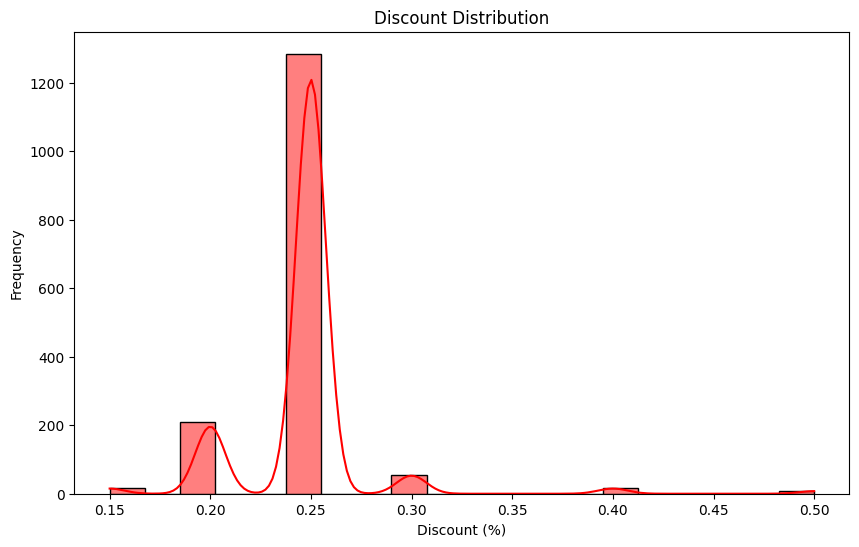

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df["Discount_cleaned"], bins=20, kde=True, color="red")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.title("Discount Distribution")
plt.show()


**Discount Distribution:**
The most frequent discount category is 25% off, followed by 20% off.
The highest discount of 50% is the least common.
Products with higher discounts tend to be lower in price.

# price 

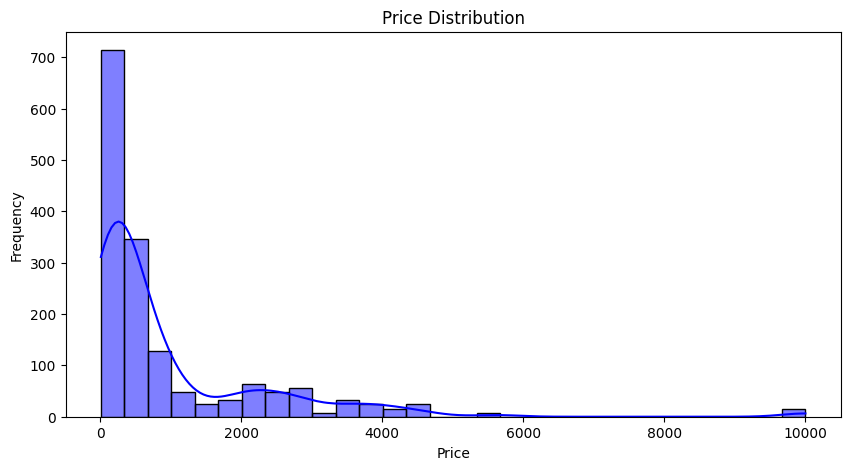

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(merged_df["Price_cleaned"], bins=30, kde=True, color="blue")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

**Price Distribution:**
The majority of products fall under the lower price range, with a few expensive outliers.
A few luxury items go up to ₹10,000+, indicating a wide pricing range.

In [20]:
from lets_plot import *
LetsPlot.setup_html()

In [21]:

# Ensure top 5 unique products by highest price
top_5_highest = merged_df.sort_values(by="Price_cleaned", ascending=False).drop_duplicates(subset="Name").head(5)
top_5_highest

,Name,Discount,Price,Item No.,Material,Designer,Warranty,Price_cleaned,Discount_cleaned
1201,Argali Rug by Hella Jongerius,25% off,"$10,001.25",100085979,"98% argali wool, 2% silk",Hella Jongerius,2-year warranty,10001.25,0.25
792,Nelson Thin Edge Double Dresser,25% off,"$5,621.25",10002007,"Walnut, white ash or santos palisander veneer ...",George Nelson,5-year warranty,5621.25,0.25
384,Merger Rug by Hella Jongerius,30% off,"$4,665.50",100085192,"80% wool, 20% cotton",Hella Jongerius,2-year warranty,4665.50,0.30
404,Eames Executive Chair,20% off,"$4,420.00",100529336,Tubular steel column,Charles and Ray Eames,12-year warranty,4420.00,0.20
1198,Multitone Rug by Hella Jongerius,25% off,"$4,368.75",10004799,100% wool,Hella Jongerius,2-year warranty,4368.75,0.25


In [22]:

# Define a mild color palette
soft_colors = ["#A6CEE3", "#B2DF8A", "#FB9A99", "#FDBF6F", "#CAB2D6"]

# Create the bar plot with soft colors and tooltips
p = ggplot(top_5_highest, aes(x="Name", y="Price_cleaned", fill="Name")) + \
    geom_bar(stat="identity", tooltips=layer_tooltips().line("@Name").line("Price: ₹@Price_cleaned")) + \
    scale_fill_manual(values=soft_colors) + \
    ggsize(800, 500) + \
    labs(x="Product Name", y="Price (₹)", title="Top 5 Highest Priced Products") + \
    theme(axis_text_x=element_text(angle=45, hjust=1), 
          panel_background=element_rect(fill="#F7F7F7"),  # Light background
          panel_grid_major=element_line(color="#E0E0E0"))  # Subtle gridlines

# Display plot
p.show()


**Top Priced Products:**
The most expensive product is the Argali Rug by Hella Jongerius (₹10,001.25).
Other high-priced products include Nelson Thin Edge Double Dresser, Merger Rug by Hella Jongerius, and Eames Executive Chair.

In [23]:
# Find the product with the lowest price
lowest_price_product = merged_df.loc[merged_df["Price_cleaned"].idxmin(), ["Name", "Price_cleaned"]]

# Print the result
print("Lowest Priced Product:")
print(f"Name: {lowest_price_product['Name']}")
print(f"Price: {lowest_price_product['Price_cleaned']} ₹")


Lowest Priced Product:
Name: Colour Storage
Price: 10.0 ₹


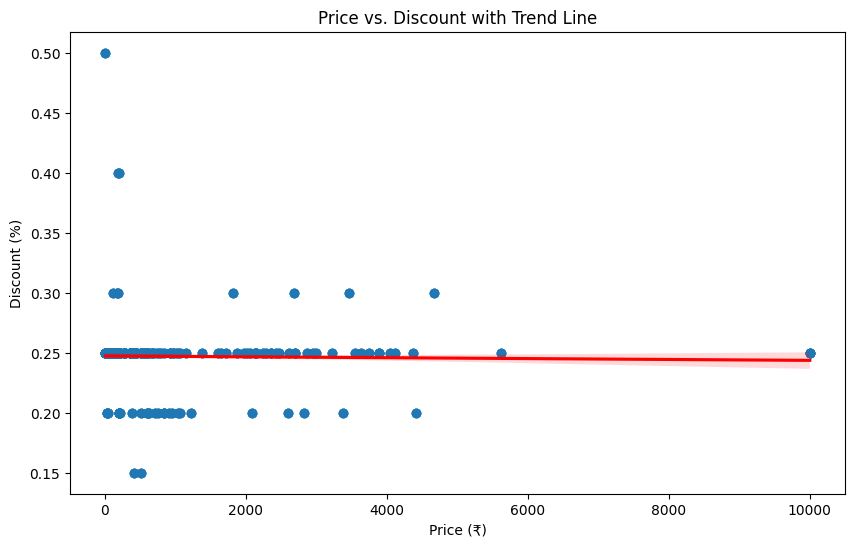

In [24]:
plt.figure(figsize=(10, 6))
sns.regplot(x=merged_df["Price_cleaned"], y=merged_df["Discount_cleaned"], scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.xlabel("Price (₹)")
plt.ylabel("Discount (%)")
plt.title("Price vs. Discount with Trend Line")
plt.show()

**Price vs Discount**
The scatter plot with a trend line suggests no strong correlation between discount percentage and price.
Higher-priced items generally have lower discounts, while lower-priced items tend to have higher discounts.

C:\Users\gthri\AppData\Local\Temp\ipykernel_33968\2326191180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=merged_df["Warranty"], y=merged_df["Price_cleaned"], palette="coolwarm")


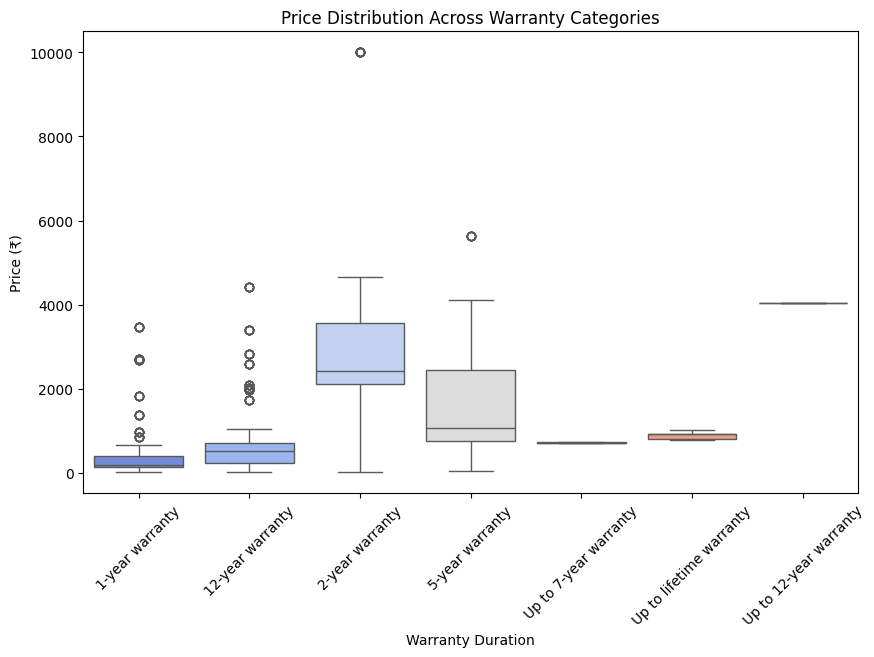

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=merged_df["Warranty"], y=merged_df["Price_cleaned"], palette="coolwarm")
plt.xlabel("Warranty Duration")
plt.ylabel("Price (₹)")
plt.title("Price Distribution Across Warranty Categories")
plt.xticks(rotation=45)
plt.show()

**Price by Warranty**
1-year warranty is the most common, followed by 2-year warranty.
High-priced products tend to have longer warranties.

# Material VS price 

C:\Users\gthri\AppData\Local\Temp\ipykernel_33968\534303650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Material", y="Price_cleaned", data=filtered_df, palette="coolwarm")


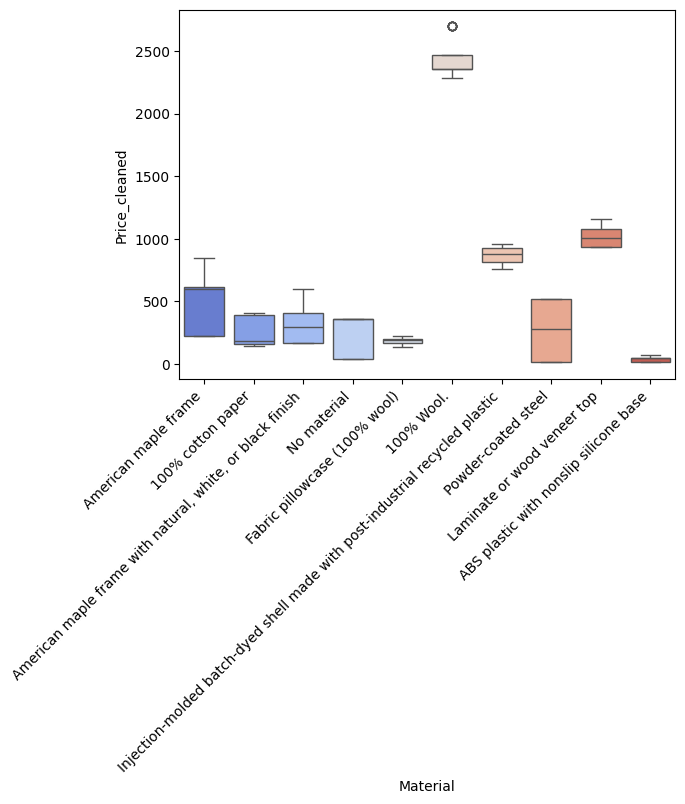

In [26]:
top_materials = merged_df["Material"].value_counts().nlargest(10).index
filtered_df = merged_df[merged_df["Material"].isin(top_materials)]
sns.boxplot(x="Material", y="Price_cleaned", data=filtered_df, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.show()


**Price by Material**
Laminates, wool, and veneer tops are among the highest-priced materials.
PVC plastic and cotton paper tend to be more affordable.

### discount and avg price

In [27]:
### Group by Discount and Compare Price ###
discount_price = merged_df.groupby("Discount_cleaned")["Price_cleaned"].mean().reset_index()

In [28]:
discount_price 

,Discount_cleaned,Price_cleaned
0,0.15,467.500000
1,0.20,1052.615385
2,0.25,947.210280
3,0.30,1874.500000
4,0.40,202.500000
5,0.50,10.000000


In [29]:
discount_warranty =  merged_df.groupby("Discount_cleaned")["Name"].count().reset_index()
discount_warranty

,Discount_cleaned,Name
0,0.15,16
1,0.20,208
2,0.25,1284
3,0.30,56
4,0.40,16
5,0.50,8


# DESIGNER

count of designs designed by designer

In [30]:
designer_count = merged_df["Designer"].value_counts()
print(designer_count)


Designer
Alexander Girard                       200
Maharam Design Studio                  200
Sam Hecht and Kim Colin                168
Charles and Ray Eames                  160
George Nelson                          160
No designer                            153
Hella Jongerius                         56
Steve Frykholm                          40
Studio 7.5                              40
Linda Powell                            32
Enzo Mari                               27
Michael Anastassiades                   24
Observatory                             24
Brian Alexander                         24
Thomas Jenkins and Sverre Uhnger        24
FAILE and Deluxx Fluxx                  24
David Irwin                             24
John Massey                             16
Philip Mitchell                         16
Dorothee Becker                         16
Jeff Weber                              16
Nathan Yong                             16
Afteroom                                16
Co

In [ ]:
top_10 = designer_count.head(10)
top_10 

Designer
Alexander Girard           25
Maharam Design Studio      25
Sam Hecht and Kim Colin    21
Charles and Ray Eames      20
No designer                20
George Nelson              20
Enzo Mari                   8
Hella Jongerius             7
Steve Frykholm              5
Studio 7.5                  5
Name: count, dtype: int64

In [ ]:
# Bottom 10 Designers
bottom_10 = designer_count.tail(10)

In [ ]:
# Combine both
designer_compare = pd.concat([top_10, bottom_10])

C:\Users\gthri\AppData\Local\Temp\ipykernel_5832\818514902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=designer_compare.values, y=designer_compare.index, palette="coolwarm")


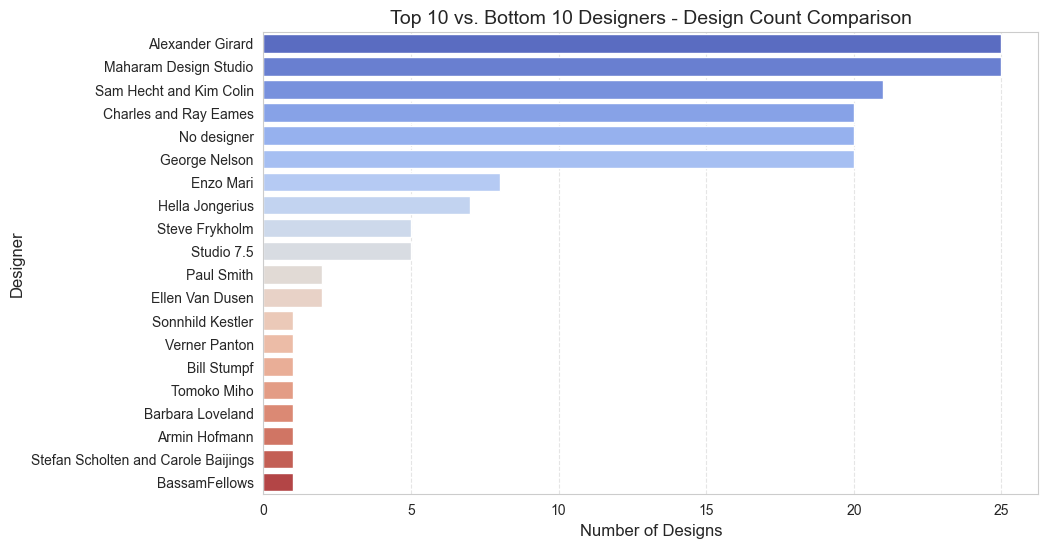

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=designer_compare.values, y=designer_compare.index, palette="coolwarm")

# Titles and Labels
plt.xlabel("Number of Designs", fontsize=12)
plt.ylabel("Designer", fontsize=12)
plt.title("Top 10 vs. Bottom 10 Designers - Design Count Comparison", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Show the plot
plt.show()

**Top Designers:**
The most active designers are:
Alexander Girard & Maharam Design Studio (25 products each)
Sam Hecht and Kim Colin (21 products)
Charles and Ray Eames (20 products)
Hella Jongerius & Enzo Mari are also among the top designers.

In [ ]:
print(merged_df[['Designer', 'Price']].isnull().sum())


Designer    0
Designer    0
Price       0
dtype: int64


In [ ]:
print(merged_df.dtypes)


Name                 object
Discount             object
Price                object
Item No.              int64
Material             object
Designer             object
Warranty             object
Price_cleaned       float64
Discount_cleaned    float64
Designer             object
dtype: object


# warranty 

In [34]:
# Count the number of products in each warranty category
warranty_counts = merged_df["Warranty"].value_counts()

C:\Users\gthri\AppData\Local\Temp\ipykernel_33968\250174185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=warranty_counts.index, y=warranty_counts.values, palette="viridis")


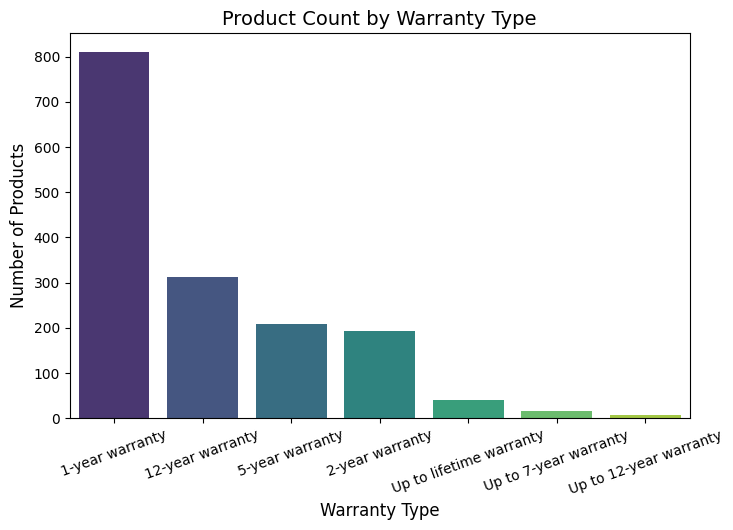

In [35]:
# Plot the warranty distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=warranty_counts.index, y=warranty_counts.values, palette="viridis")

# Labels and Titles
plt.xlabel("Warranty Type", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.title("Product Count by Warranty Type", fontsize=14)
plt.xticks(rotation=20)

plt.show()

only 1,2,no warranty only present in the data

## most used material

In [ ]:
# Count occurrences of each material
material_counts = merged_df["Material"].value_counts()

C:\Users\gthri\AppData\Local\Temp\ipykernel_17224\719315415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=material_counts.head(10).values, y=material_counts.head(10).index, palette="mako")


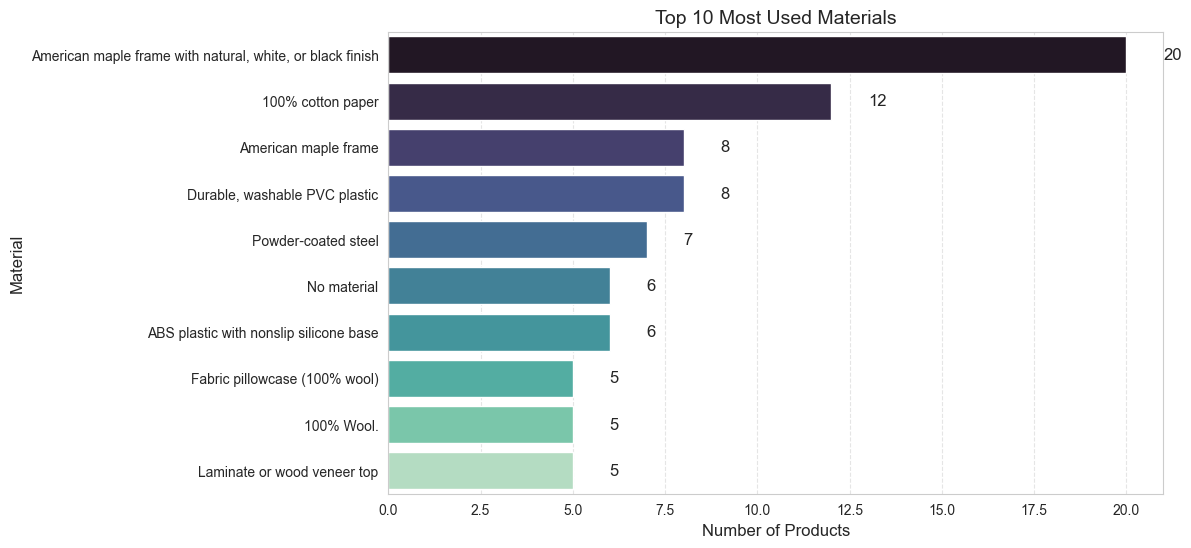

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=material_counts.head(10).values, y=material_counts.head(10).index, palette="mako")

# Add count labels on bars
for index, value in enumerate(material_counts.head(10).values):
    plt.text(value + 1, index, str(value), va="center", fontsize=12)  # Adjust text position

# Labels and Titles
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Material", fontsize=12)
plt.title("Top 10 Most Used Materials", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Show the plot
plt.show()

**Most Used Materials**
American maple frame (20 products) is the most used material.
Other commonly used materials: 100% cotton paper, PVC plastic, and powder-coated steel.

**conclude:**
* Discounts are applied strategically—budget-friendly products receive bigger discounts, while premium-priced items retain their high value.

* There is a wide gap in product pricing, reflecting a mix of both affordable and premium items.

* Warranty serves as a key value indicator, with longer warranties justifying higher product prices.

* Material selection directly influences pricing, with natural and premium materials commanding higher prices.

* The discounting strategy is demand-driven—luxury products maintain exclusivity with lower discounts, while budget items attract customers with bigger discounts.

**Final Takeaways**
##### Discounts are applied strategically, with bigger discounts on cheaper products and lower discounts on premium items.
##### Luxury products justify their high prices with premium materials and long warranties.
##### Designer products dominate the market, but non-branded functional items also have a presence.
##### Material choice significantly affects product pricing, with wood, wool, and steel leading premium categories.
##### Warranty acts as a key selling point, reinforcing product quality perception.

 **further insights and recommendations**   

### **1. Pricing & Discount Strategy Recommendations**  
 **For budget products:** Since lower-priced items receive higher discounts, consider **promotional campaigns** to attract cost-conscious buyers. **Bundle offers** (e.g., “Buy 2, Get 1 Free”) could further boost sales.  

 **For premium products:** Since discounts are minimal on high-end items, focus on **exclusive benefits** like extended warranties, personalization, or free accessories instead of heavy discounts. 

### **2. Product Positioning & Designer Impact**  
 **Leverage Top Designers**: Since Alexander Girard & Maharam Design Studio contribute the most designs, you can **highlight their work in marketing campaigns** to increase perceived value.  

 **Expand No-Designer Products**: Given their demand, consider launching a **budget-friendly, in-house brand** to compete with non-branded options.  

### **3. Warranty-Price Connection – Trust & Value**  
 **Higher warranties = better sales for expensive items**: If a premium product lacks a **minimum 2-year warranty**, consider extending coverage to **increase trust** and justify the price.  

 **Introduce paid extended warranties**: Offer customers an option to **purchase additional coverage** for mid-range products.  

### **4. Overall Market Strategy**  
 **Segmentation Approach**:  
- **Luxury Segment** – Focus on exclusivity, customization, and longer warranties.  
- **Mid-Range Segment** – Offer balanced pricing with moderate discounts and extended warranty add-ons.  
- **Budget Segment** – Use higher discounts and bundle offers to drive bulk purchases.  

